# EXPLORATORIO

# Comportamiento de Fidelidad 2

# 0. Importaciones y Configuración

In [1]:
from astropy.io import fits #Apertura de archivos .fits
import numpy as np #Manipulación de arrays
import matplotlib.pyplot as plt #Visualización de datos
import os #Manipulación de directorios
import sys #Manipulación de rutas

sys.path.append('../../src') #Añadir ruta de src a sys.path

DATA_DIR = '/Users/kuky/Documents/practica/Denoiser3D-IFU/data/mock_cubes'

mkdir -p failed for path /.matplotlib: [Errno 30] Read-only file system: '/.matplotlib'
Matplotlib created a temporary cache directory at /var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/matplotlib-b2snbrev because there was an issue with the default path (/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


## 0.1 Parámetros Matplotlib

In [2]:
okabe_ito = ['#E69F00', '#56B4E9', '#009E73', '#F0E442',
             '#0072B2', '#D55E00', '#CC79A7', '#000000']

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=okabe_ito)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.labelsize": 12,
    "figure.figsize": (3.5, 2.625), # 4:3 ratio for single-column
    "savefig.dpi": 600
})

## 0.2. Definición de Funciones

In [3]:
def chi_cuadrado(valor_observado, valor_referencia):
    mask = valor_referencia > 0
    return np.sum((valor_observado[mask] - valor_referencia[mask]) ** 2 / valor_referencia[mask])

def cargar_momentos_log(
    subdir, momento_idx, umbral_inicial, umbral_step, cubo, cube_dir,
    umbral_max=None
    ):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    if umbral_max is None:
        flux_max = np.nanmax(np.squeeze(hdu[0].data))
        cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    else:
        cantidad = int(np.floor(np.log(umbral_max / umbral_inicial) / np.log(umbral_step))) + 1
    momentos = []
    for k in range(cantidad):
        umbral = umbral_inicial * (umbral_step ** k)
        ruta = os.path.join(
            DATA_DIR, cube_dir, subdir,
            f'iter_flux_{umbral:.3e}',
            f'iter_flux_{umbral:.3e}_moment{momento_idx}.fits',
        )
        hdu = fits.open(ruta)
        momento = np.squeeze(hdu[0].data)
        momentos.append(np.nan_to_num(momento).flatten())
    return momentos

def flux_max(cubo, cube_dir):
    hdu = fits.open(os.path.join(DATA_DIR, cube_dir, f'{cubo}.fits'))
    flux_max = np.nanmax(np.squeeze(hdu[0].data))
    return flux_max

def umbrales_log(flux_max, umbral_inicial, umbral_step):
    cantidad = int(np.floor(np.log(flux_max / umbral_inicial) / np.log(umbral_step))) + 1
    return umbral_inicial * umbral_step ** np.arange(cantidad)

# 1. Cube Isolated

## 1.1. Isolated AC3

In [4]:
CUBE_DIR_N50 = 'isolated_sub_AC3_N50_width1'
CUBE_DIR_N25 = 'isolated_sub_AC3_N25_width1'
CUBE_DIR_N20 = 'isolated_sub_AC3_N20_width1'
CUBE_DIR_N15 = 'isolated_sub_AC3_N15_width1'

### 1.1.1. Apertura Momentos de referencia

In [5]:
hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR_N50, 'moments_ref', 'notnoisy_moment0_AC3.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat_N50 = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)

hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR_N25, 'moments_ref', 'notnoisy_moment0_AC3.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat_N25 = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)

hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR_N20, 'moments_ref', 'notnoisy_moment0_AC3.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat_N20 = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)

hdu = fits.open(os.path.join(DATA_DIR, CUBE_DIR_N15, 'moments_ref', 'notnoisy_moment0_AC3.fits'))
moment_0_ref = np.squeeze(hdu[0].data)
moment_0_ref_flat_N15 = np.clip(np.nan_to_num(moment_0_ref).flatten(), 0, None)


### 1.1.2. Steps

In [6]:
IterativeMin = 1.0e-7
IterativeStep = 1.5

In [7]:
momentos_0_soft_5_N50 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_5', CUBE_DIR_N50)
momentos_0_soft_5_N25 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N25_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR_N25)
momentos_0_soft_5_N20 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N20_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR_N20)
momentos_0_soft_5_N15 = cargar_momentos_log('moments_soft_5', 0, IterativeMin, IterativeStep, 'isolated_sub_AC3_N15_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR_N15)

In [8]:
flux_max_val = flux_max('isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_5', CUBE_DIR_N50)
umbrales_soft_5_N50 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC3_N25_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR_N25)
umbrales_soft_5_N25 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC3_N20_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR_N20)
umbrales_soft_5_N20 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)

flux_max_val = flux_max('isolated_sub_AC3_N15_width1_noisy_sub_wavelets_iterative_soft_5', CUBE_DIR_N15)
umbrales_soft_5_N15 = umbrales_log(flux_max_val, IterativeMin, IterativeStep)


In [9]:
chi_cuadrado_momentos_0_soft_5_N50 = []
for momento in momentos_0_soft_5_N50:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat_N50)
    chi_cuadrado_momentos_0_soft_5_N50.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_5_N25 = []
for momento in momentos_0_soft_5_N25:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat_N25)
    chi_cuadrado_momentos_0_soft_5_N25.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_5_N20 = []
for momento in momentos_0_soft_5_N20:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat_N20)
    chi_cuadrado_momentos_0_soft_5_N20.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_5_N15 = []
for momento in momentos_0_soft_5_N15:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat_N15)
    chi_cuadrado_momentos_0_soft_5_N15.append(chi_cuadrado_momento_0)


/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_67287/3552635620.py:16: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e5)


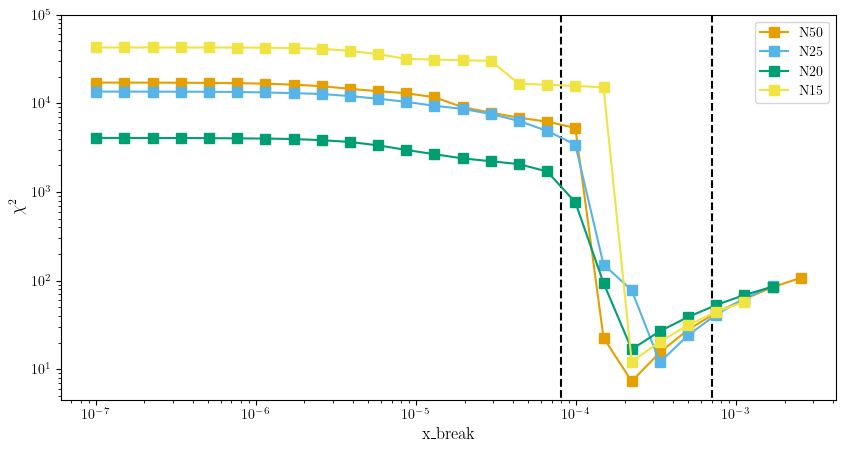

In [10]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5_N50, chi_cuadrado_momentos_0_soft_5_N50, ms=7, label='N50', marker='s')
plt.errorbar(umbrales_soft_5_N25, chi_cuadrado_momentos_0_soft_5_N25, ms=7, label='N25', marker='s')
plt.errorbar(umbrales_soft_5_N20, chi_cuadrado_momentos_0_soft_5_N20, ms=7, label='N20', marker='s')
plt.errorbar(umbrales_soft_5_N15, chi_cuadrado_momentos_0_soft_5_N15, ms=7, label='N15', marker='s')


plt.vlines(8e-5, 0, 1e5, color='black', linestyle='--')
plt.vlines(7e-4, 0, 1e5, color='black', linestyle='--')

plt.xlabel('x_break')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.xscale('log')
plt.ylim(0,1e5)
plt.legend()

Quiero revisar con mayor detalle la zona delimitada por las dos **vlines** definidas en el gráfico anterior. Vamos a realizar un barrido de máscaras dentro de ese rango.

### 1.1.3. Zona de interés I

In [20]:
IterativeMin = 8.0e-5
IterativeMax = 7.0e-4
IterativeStep = 1.2

In [22]:
momentos_0_soft_5_N50 = cargar_momentos_log(
    'moments_soft_5',
    0,
    IterativeMin,
    IterativeStep,
    'isolated_sub_AC3_N50_width1_noisy_2_sub_wavelets_iterative_soft_5',
    CUBE_DIR_N50,
    umbral_max=IterativeMax
    )

momentos_0_soft_5_N25 = cargar_momentos_log(
    'moments_soft_5',
    0,
    IterativeMin,
    IterativeStep,
    'isolated_sub_AC3_N25_width1_noisy_sub_wavelets_iterative_soft_5',
    CUBE_DIR_N25,
    umbral_max=IterativeMax
    )


momentos_0_soft_5_N20 = cargar_momentos_log(
    'moments_soft_5',
    0,
    IterativeMin,
    IterativeStep,
    'isolated_sub_AC3_N20_width1_noisy_sub_wavelets_iterative_soft_5',
    CUBE_DIR_N20,
    umbral_max=IterativeMax
    )


momentos_0_soft_5_N15 = cargar_momentos_log(
    'moments_soft_5',
    0,
    IterativeMin,
    IterativeStep,
    'isolated_sub_AC3_N15_width1_noisy_sub_wavelets_iterative_soft_5',
    CUBE_DIR_N15,
    umbral_max=IterativeMax
    )

In [23]:
chi_cuadrado_momentos_0_soft_5_N50 = []
for momento in momentos_0_soft_5_N50:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat_N50)
    chi_cuadrado_momentos_0_soft_5_N50.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_5_N25 = []
for momento in momentos_0_soft_5_N25:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat_N20)
    chi_cuadrado_momentos_0_soft_5_N25.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_5_N20 = []
for momento in momentos_0_soft_5_N20:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat_N20)
    chi_cuadrado_momentos_0_soft_5_N20.append(chi_cuadrado_momento_0)

chi_cuadrado_momentos_0_soft_5_N15 = []
for momento in momentos_0_soft_5_N15:
    chi_cuadrado_momento_0 = chi_cuadrado(momento, moment_0_ref_flat_N15)
    chi_cuadrado_momentos_0_soft_5_N15.append(chi_cuadrado_momento_0)


In [24]:
umbrales_soft_5_N50 = umbrales_log(IterativeMax, IterativeMin, IterativeStep)

umbrales_soft_5_N25 = umbrales_log(IterativeMax, IterativeMin, IterativeStep)

umbrales_soft_5_N20 = umbrales_log(IterativeMax, IterativeMin, IterativeStep)

umbrales_soft_5_N15 = umbrales_log(IterativeMax, IterativeMin, IterativeStep)


/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_67287/707561200.py:12: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e5)


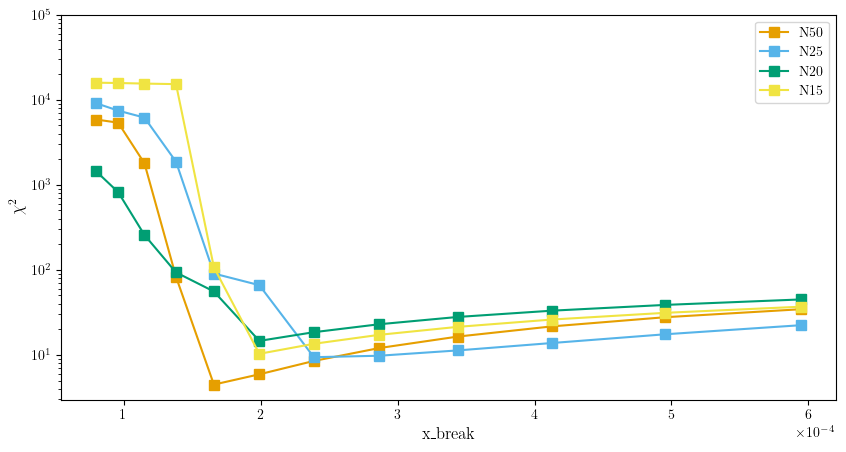

In [28]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5_N50, chi_cuadrado_momentos_0_soft_5_N50, ms=7, label='N50', marker='s')
plt.errorbar(umbrales_soft_5_N25, chi_cuadrado_momentos_0_soft_5_N25, ms=7, label='N25', marker='s')
plt.errorbar(umbrales_soft_5_N20, chi_cuadrado_momentos_0_soft_5_N20, ms=7, label='N20', marker='s')
plt.errorbar(umbrales_soft_5_N15, chi_cuadrado_momentos_0_soft_5_N15, ms=7, label='N15', marker='s')

plt.xlabel('x_break')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
#plt.xscale('log')
plt.ylim(0,1e5)
plt.legend()

Vamos a realizar el ajuste del **eje x** según el **x_break** calculado por el **broken knee** de cada cubo.

In [39]:
bk_N50 = 1.54e-5
bk_N25 = 2.60e-5
bk_N20 = 2.25e-5

umbrales_soft_5_N50_ajustados =  umbrales_soft_5_N50 / bk_N50
umbrales_soft_5_N25_ajustados = umbrales_soft_5_N25 / bk_N25
umbrales_soft_5_N20_ajustados = umbrales_soft_5_N20 / bk_N20

/var/folders/2b/5tqr_dzn551f21glw27fr5t40000gn/T/ipykernel_67287/786430904.py:10: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1e5)


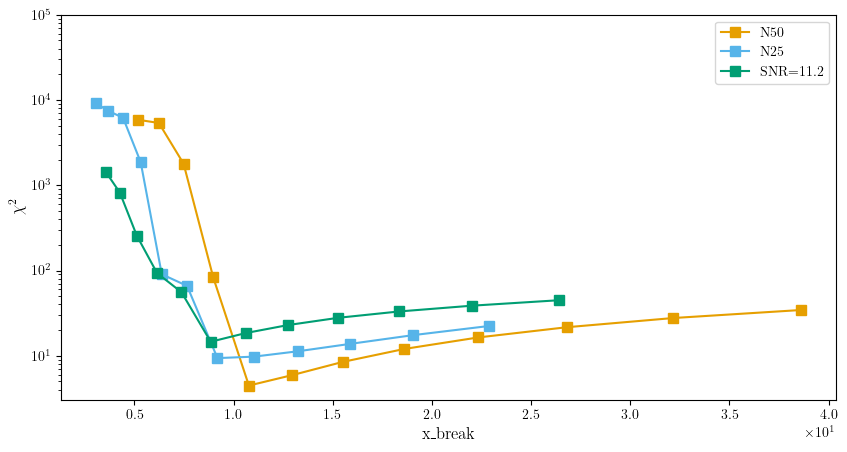

In [40]:
plt.figure(figsize=(10, 5))
plt.errorbar(umbrales_soft_5_N50_ajustados, chi_cuadrado_momentos_0_soft_5_N50, ms=7, label='N50', marker='s')
plt.errorbar(umbrales_soft_5_N25_ajustados, chi_cuadrado_momentos_0_soft_5_N25, ms=7, label='N25', marker='s')
plt.errorbar(umbrales_soft_5_N20_ajustados, chi_cuadrado_momentos_0_soft_5_N20, ms=7, label='SNR=11.2', marker='s')

plt.xlabel('x_break')
plt.ylabel('$\chi^2$')
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
plt.yscale('log')
plt.ylim(0,1e5)
plt.legend()